In [2]:
import os
import numpy as np
import scanpy as sc
import squidpy as sq
from anndata import AnnData
import scipy.sparse as sp
import warnings
warnings.filterwarnings('ignore')
import os
import pandas as pd
import matplotlib.pyplot as plt
def format_data_neighs_colapse(
    adata: AnnData,
    spatial_key: str = "spatial",
    neighs: int = 10
) -> AnnData:
    """Pseudobin each cell’s expression by summing over its spatial neighbors."""
    if spatial_key not in adata.obsm:
        coords = adata.obs[['X','Y']].values.astype(float)
        adata.obsm[spatial_key] = coords

    ad = adata.copy()
    print(f"    → Computing spatial neighbors (k={neighs})…", end="", flush=True)
    sq.gr.spatial_neighbors(ad, spatial_key=spatial_key, n_neighs=neighs)
    print("done")

    C = ad.obsp['spatial_connectivities'].astype(bool).astype(int)
    C = C + sp.eye(C.shape[0], format='csr')
    X = ad.X.copy() if not isinstance(ad.X, np.ndarray) else ad.X
    Xc = C.dot(X)

    print("    → Pseudobinning complete")
    return AnnData(
        X    = Xc,
        obs  = ad.obs.copy(),
        var  = ad.var.copy(),
        obsm = ad.obsm.copy(),
        uns  = ad.uns.copy()
    )


def domains_by_rbd(
    adata: AnnData,
    hyperparams: dict,
    sample_key: str = 'sample',
    cell_id_key: str = None,
    checkpoint_dir: str = './checkpoints',
    force_rerun: bool = False
) -> (AnnData, AnnData):
    """
    Read-based domains with checkpointed saves, force-rerun option, and printouts.
    """
    os.makedirs(checkpoint_dir, exist_ok=True)

    # A) ensure unique IDs
    if cell_id_key is None:
        print("1) Ensuring unique cell IDs…", end="", flush=True)
        adata.obs_names_make_unique()
        cell_id_key = 'cell_id'
        adata.obs[cell_id_key] = adata.obs_names
        print("done\n")

    def load_or_compute(path, compute_fn, step_name):
        if (not force_rerun) and os.path.exists(path):
            print(f"{step_name}: Loading from checkpoint…", end="", flush=True)
            ad = sc.read_h5ad(path)
            print("loaded\n")
            return ad, False
        else:
            print(f"{step_name}: Computing…", flush=True)
            ad = compute_fn()
            ad.write_h5ad(path)
            print(f"{step_name}: Saved to {path}\n")
            return ad, True

    # 1) PSEUDOBINNING
    pseudobin_path = os.path.join(checkpoint_dir, 'pseudobinned.h5ad')
    def compute_pseudobin():
        parts = []
        for samp in adata.obs[sample_key].unique():
            print(f"  Sample '{samp}':")
            sub = adata[adata.obs[sample_key] == samp].copy()
            parts.append(format_data_neighs_colapse(
                sub, spatial_key='spatial', neighs=hyperparams['neighbors']
            ))
        return sc.concat(parts, merge='same')

    pseudobinned, _ = load_or_compute(
        pseudobin_path, compute_pseudobin, "Step 1) Pseudobinning"
    )

    # 2) FILTERING
    filtered_path = os.path.join(checkpoint_dir, 'filtered.h5ad')
    def compute_filtered():
        ad_neigh = pseudobinned.copy()
        ad_neigh.X = np.nan_to_num(ad_neigh.X)
        sc.pp.filter_cells(ad_neigh, min_counts=4)
        ad_neigh.raw = ad_neigh
        return ad_neigh

    adata_neigh, _ = load_or_compute(
        filtered_path, compute_filtered, "Step 2) Filtering"
    )

    # 3) UMAP
    umap_path = os.path.join(checkpoint_dir, 'umap.h5ad')
    def compute_umap():
        nn  = hyperparams.get('n_neighbors', 20)
        pcs = hyperparams.get('n_pcs', None)
        if pcs is None:
            sc.pp.neighbors(adata_neigh, n_neighbors=nn, use_rep='X')
        else:
            sc.tl.pca(adata_neigh, n_comps=pcs, svd_solver='arpack')
            sc.pp.neighbors(adata_neigh, n_neighbors=nn, n_pcs=pcs)
        sc.tl.umap(adata_neigh, min_dist=hyperparams.get('min_dist',0.1))
        return adata_neigh

    adata_neigh, _ = load_or_compute(
        umap_path, compute_umap, "Step 3) UMAP"
    )

    # 4) CLUSTERING at one or many resolutions
    algo = hyperparams['clustering_algorithm'].lower()
    res_list = hyperparams.get('resolutions',
               [hyperparams.get('resolution')])

    for res in res_list:
        key = f"rbd_domain_{res}"
        chk = os.path.join(checkpoint_dir, f"clustered_{res}.h5ad")

        def compute_cluster():
            if algo == 'leiden':
                sc.tl.leiden(adata_neigh, resolution=res, key_added=key)
            else:
                sc.tl.louvain(adata_neigh, resolution=res, key_added=key)
            return adata_neigh

        adata_neigh, _ = load_or_compute(
            chk, compute_cluster,
            f"Step 4) Clustering (res={res})"
        )

        # map back to original
        print(f"  → Mapping rbd_domain_{res} back to original…", end="", flush=True)
        mapping = dict(zip(
            adata_neigh.obs[cell_id_key],
            adata_neigh.obs[key]
        ))
        adata.obs[key] = adata.obs[cell_id_key].map(mapping).astype(str)
        print("done\n")

    print("All steps complete! Returning results.")
    return adata, adata_neigh

hyperparams = {
    'neighbors': 20,
    'clustering_algorithm': 'leiden',
    'resolutions': [0.1, 0.2, 0.5, 1.0],
    'n_neighbors': 20,
    'n_pcs': 30,
    'min_dist': 0.5
}

In [3]:
adata_sub = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation.h5ad')

In [4]:
adata_sub = adata_sub[adata_sub.obs.condition == 'mtDSB']

In [5]:
adata_sub.obs['cell_id'] = adata_sub.obs.index

In [6]:
adata_sub

AnnData object with n_obs × n_vars = 508528 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [ ]:
# 3) Call domains_by_rbd, forcing a fresh run
adata_annotated, adata_pseudobinned = domains_by_rbd(
    adata_sub,
    hyperparams,
    sample_key='sample_id',
    cell_id_key='cell_id',               # or whatever your unique-ID column is
    checkpoint_dir='../results/rbd_checkpoints_mtDSB',  # where to store (or load) .h5ad files
    force_rerun=False                     # overwrite any existing checkpoints
)

Step 1) Pseudobinning: Loading from checkpoint…loaded

Step 2) Filtering: Loading from checkpoint…loaded

Step 3) UMAP: Loading from checkpoint…

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec

def plot_spatial_compact(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=18,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,          # <- NEW: dict {category: "#hex"} or list in desired order
):
    # --- categories from the FULL object (freeze order) ---
    cats = ad.obs[color].astype("category").cat.categories

    # --- build a shared color list in that order ---
    if isinstance(palette, dict):
        cols_list = [palette[c] for c in cats]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cats):
            raise ValueError("Palette list shorter than number of categories.")
        cols_list = list(palette)[:len(cats)]
    elif f"{color}_colors" in ad.uns:
        # reuse existing palette if present on the full object
        cols_list = list(ad.uns[f"{color}_colors"])
        if len(cols_list) != len(cats):
            raise ValueError(f"{color}_colors length does not match categories.")
    else:
        base = sc.plotting.palettes.default_64
        reps = int(np.ceil(len(cats) / len(base)))
        cols_list = (base * reps)[:len(cats)]

    # store on the full object too (handy if you plot elsewhere later)
    ad.uns[f"{color}_colors"] = cols_list

    # --- layout ---
    sids = list(ad.obs[groupby].unique())
    n = len(sids)
    rows = int(np.ceil(n / cols))

    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width
    fig = plt.figure(figsize=(fig_w, height), constrained_layout=False)

    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # --- panels ---
    for i, sid in enumerate(sids):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        ad_sub = ad[ad.obs[groupby] == sid].copy()

        # CRUCIAL: force identical categories & palette on each subset
        ad_sub.obs[color] = ad_sub.obs[color].astype("category")
        ad_sub.obs[color] = ad_sub.obs[color].cat.set_categories(cats)
        ad_sub.uns[f"{color}_colors"] = cols_list

        sc.pl.spatial(
            ad_sub, color=color, spot_size=spot_size,
            show=False, ax=ax, legend_loc=None, frameon=False, title=str(sid)
        )
        ax.set_xlabel(""); ax.set_ylabel("")
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # blank unused
    for j in range(n, rows*cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # --- legend ---
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cols_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cats)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.show()

In [ ]:
for domain in ['rbd_domain_0.1','rbd_domain_0.2','rbd_domain_0.5','rbd_domain_1',]:
    if domain in adata_pseudobinned.obs.columns: 
        plot_spatial_compact(adata_pseudobinned, color=domain, groupby="sample_id",spot_size=20,
            cols=6,
            height=8,
            legend_col_width=1.0,)
    else:
        continue

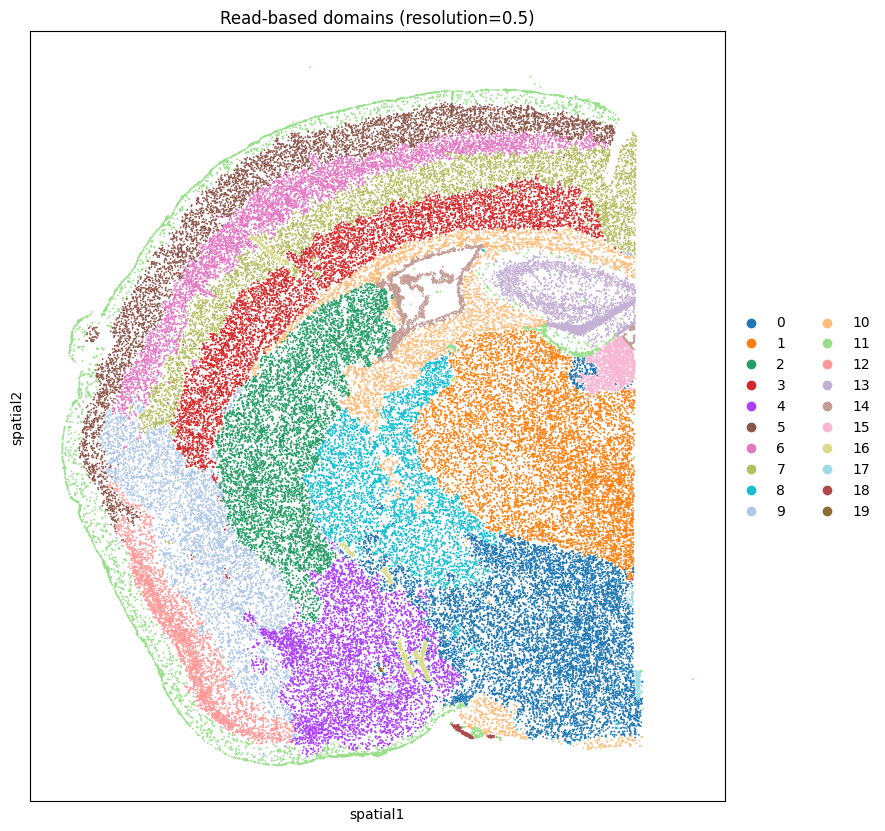

In [16]:
# 5) Plot a spatial map for your favorite resolution:
with plt.rc_context({"figure.figsize": (10,10)}):
    sc.pl.spatial(
        adata_pseudobinned,
        color='rbd_domain_0.5',
        spot_size=15,
        title="Read-based domains (resolution=0.5)"
    )

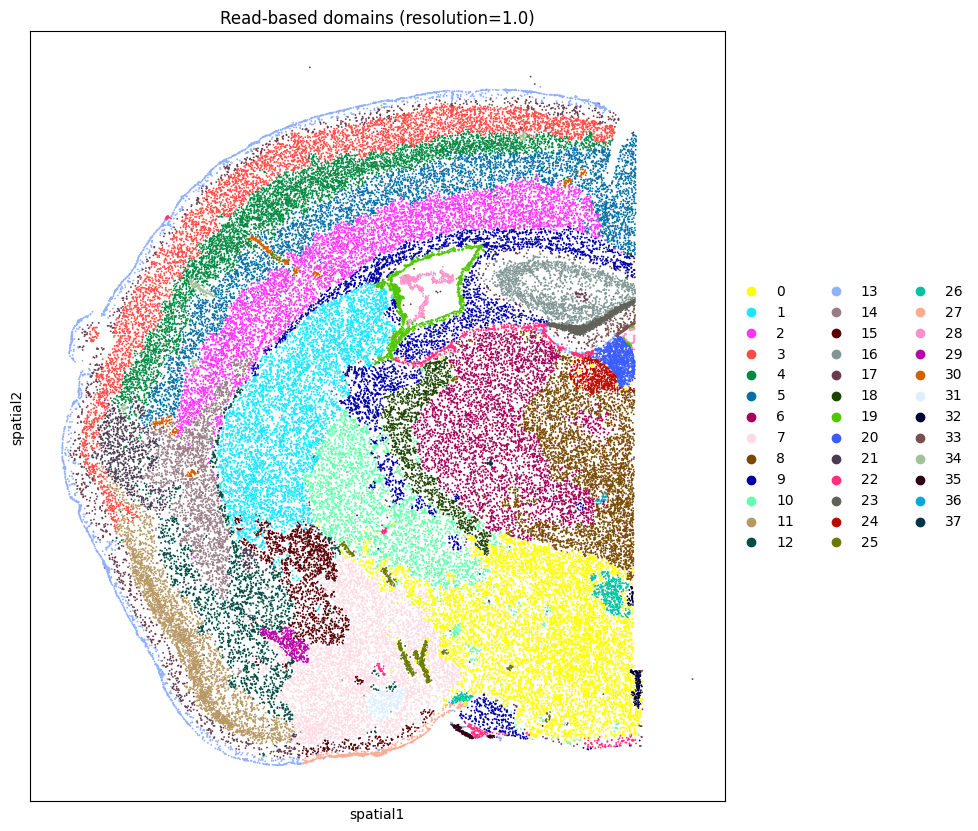

In [17]:
# 5) Plot a spatial map for your favorite resolution:
with plt.rc_context({"figure.figsize": (10,10)}):
    sc.pl.spatial(
        adata_pseudobinned,
        color='rbd_domain_1.0',
        spot_size=15,
        title="Read-based domains (resolution=1.0)"
    )